In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
# Reading the CSV file into a DataFrame
df = pd.read_csv('/Users/alanphan/Documents/WGU MSDA/Course Materials/D600/Task 3/data/D600 Task 3 Dataset 1 Housing Information.csv')
df

,ID,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,...,RenovationQuality,LocalAmenities,TransportAccess,Fireplace,HouseColor,Garage,Floors,Windows,PreviousSalePrice,IsLuxury
0,4922,255614.8992,566.62,1.000000,4,779.42,20.56,5.62,39.46,10.08,...,4.93,4.44,4.55,Yes,Blue,No,1,13,181861.54230,0
1,5009,155586.0947,1472.34,1.000000,2,656.13,15.62,5.63,40.51,7.89,...,4.08,5.56,6.83,No,Green,No,1,17,50042.59757,0
2,4450,131050.8324,550.00,1.779354,3,754.57,12.47,9.20,48.38,23.74,...,4.26,8.07,8.48,Yes,Green,Yes,2,34,48400.34440,0
3,1070,151361.7125,941.81,2.035254,2,439.59,22.22,7.08,94.67,5.22,...,4.45,5.00,6.27,Yes,Red,No,1,14,84594.12145,0
4,400,113167.6128,550.00,1.064644,3,353.03,8.28,5.93,16.80,43.13,...,3.36,5.46,6.99,No,White,Yes,1,21,22934.59654,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,6987,307821.1758,550.00,2.111022,4,892.35,11.89,7.97,28.18,19.23,...,4.76,3.81,6.87,No,White,Yes,1,18,241131.63070,1
6996,6995,421368.8869,1726.12,4.056115,2,943.19,34.06,5.82,90.45,17.60,...,5.31,9.84,10.00,No,White,Yes,1,18,481604.80730,1
6997,6996,473382.5348,1026.36,2.077177,5,149.31,0.10,8.81,31.79,11.59,...,4.98,7.47,2.96,No,Green,No,1,13,380555.49390,1
6998,6998,343397.9756,2218.22,1.000000,4,526.81,11.18,9.20,15.21,3.96,...,4.68,7.66,6.12,No,Blue,Yes,1,10,442610.31710,0


In [3]:
# Selecting continuous variables for features
continuous_vars = ['SquareFootage', 'NumBathrooms', 'NumBedrooms', 'BackyardSpace',
                   'CrimeRate', 'SchoolRating', 'AgeOfHome', 'DistanceToCityCenter',
                   'EmploymentRate', 'PropertyTaxRate', 'RenovationQuality',
                   'LocalAmenities', 'TransportAccess', 'Floors', 'Windows',
                   'PreviousSalePrice']

# Separating the independent and dependent variables
X = df[continuous_vars]
y = df['Price']

X

,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,EmploymentRate,PropertyTaxRate,RenovationQuality,LocalAmenities,TransportAccess,Floors,Windows,PreviousSalePrice
0,566.62,1.000000,4,779.42,20.56,5.62,39.46,10.08,97.29,1.84,4.93,4.44,4.55,1,13,181861.54230
1,1472.34,1.000000,2,656.13,15.62,5.63,40.51,7.89,93.22,0.95,4.08,5.56,6.83,1,17,50042.59757
2,550.00,1.779354,3,754.57,12.47,9.20,48.38,23.74,96.60,1.87,4.26,8.07,8.48,2,34,48400.34440
3,941.81,2.035254,2,439.59,22.22,7.08,94.67,5.22,91.45,1.45,4.45,5.00,6.27,1,14,84594.12145
4,550.00,1.064644,3,353.03,8.28,5.93,16.80,43.13,86.50,1.26,3.36,5.46,6.99,1,21,22934.59654
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,550.00,2.111022,4,892.35,11.89,7.97,28.18,19.23,96.91,1.39,4.76,3.81,6.87,1,18,241131.63070
6996,1726.12,4.056115,2,943.19,34.06,5.82,90.45,17.60,92.25,1.67,5.31,9.84,10.00,1,18,481604.80730
6997,1026.36,2.077177,5,149.31,0.10,8.81,31.79,11.59,94.57,1.45,4.98,7.47,2.96,1,13,380555.49390
6998,2218.22,1.000000,4,526.81,11.18,9.20,15.21,3.96,99.90,1.52,4.68,7.66,6.12,1,10,442610.31710


In [4]:
# Descriptive statistics of continuous variables
print(X.describe())

       SquareFootage  NumBathrooms  NumBedrooms  BackyardSpace    CrimeRate  \
count    7000.000000   7000.000000  7000.000000    7000.000000  7000.000000   
mean     1048.947459      2.131397     3.008571     511.507029    31.226194   
std       426.010482      0.952561     1.021940     279.926549    18.025327   
min       550.000000      1.000000     1.000000       0.390000     0.030000   
25%       660.815000      1.290539     2.000000     300.995000    17.390000   
50%       996.320000      1.997774     3.000000     495.965000    30.385000   
75%      1342.292500      2.763997     4.000000     704.012500    43.670000   
max      2874.700000      5.807239     7.000000    1631.360000    99.730000   

       SchoolRating    AgeOfHome  DistanceToCityCenter  EmploymentRate  \
count   7000.000000  7000.000000           7000.000000     7000.000000   
mean       6.942923    46.797046             17.475337       93.711349   
std        1.888148    31.779701             12.024985        4.50

In [5]:
# Descriptive statistics of dependent variable Price
print(y.describe())

count    7.000000e+03
mean     3.072820e+05
std      1.501734e+05
min      8.500000e+04
25%      1.921075e+05
50%      2.793230e+05
75%      3.918781e+05
max      1.046676e+06
Name: Price, dtype: float64


In [6]:
# Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.1322771 , -1.18782774,  0.97021289, ..., -0.43809765,
        -0.3639833 , -0.55269974],
       [ 0.99392575, -1.18782774, -0.9869889 , ..., -0.43809765,
         0.08415373, -1.26246936],
       [-1.17129301, -0.36960193, -0.00838801, ...,  2.24961801,
         1.98873612, -1.27131195],
       ...,
       [-0.05302469, -0.05692443,  1.94881378, ..., -0.43809765,
        -0.3639833 ,  0.51715353],
       [ 2.74489976, -1.18782774,  0.97021289, ..., -0.43809765,
        -0.70008607,  0.85128325],
       [ 1.18461543,  1.94959952,  0.97021289, ..., -0.43809765,
         0.30822225,  1.11837588]])

In [7]:
# Converting scaled array back to a DataFrame with the original column names
X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)
X_scaled_df

,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,EmploymentRate,PropertyTaxRate,RenovationQuality,LocalAmenities,TransportAccess,Floors,Windows,PreviousSalePrice
0,-1.132277,-1.187828,0.970213,0.957151,-0.591776,-0.700696,-0.230889,-0.615042,0.794367,0.681094,-0.037232,-0.562349,-0.733870,-0.438098,-0.363983,-0.552700
1,0.993926,-1.187828,-0.986989,0.516683,-0.865854,-0.695399,-0.197846,-0.797175,-0.109066,-1.104064,-0.468641,-0.140939,0.433066,-0.438098,0.084154,-1.262469
2,-1.171293,-0.369602,-0.008388,0.868372,-1.040621,1.195478,0.049814,0.521008,0.641205,0.741268,-0.377284,0.803473,1.277560,2.249618,1.988736,-1.271312
3,-0.251508,-0.100938,-0.986989,-0.256932,-0.499677,0.072604,1.506508,-1.019229,-0.501960,-0.101167,-0.280851,-0.351644,0.146450,-0.438098,-0.251949,-1.076429
4,-1.171293,-1.119960,-0.008388,-0.566178,-1.273088,-0.536502,-0.943973,2.133599,-1.600730,-0.482268,-0.834070,-0.178565,0.514957,-0.438098,0.532291,-1.408430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,-1.171293,-0.021391,0.970213,1.360608,-1.072800,0.543999,-0.585857,0.145929,0.710017,-0.221514,-0.123514,-0.799393,0.453539,-0.438098,0.196188,-0.233564
6996,1.589681,2.020716,-0.986989,1.542240,0.157224,-0.594764,1.373709,0.010368,-0.324381,0.340108,0.155634,1.469452,2.055517,-0.438098,0.196188,1.061246
6997,-0.053025,-0.056924,1.948814,-1.293993,-1.726927,0.988911,-0.472255,-0.489461,0.190598,-0.101167,-0.011855,0.577717,-1.547654,-0.438098,-0.363983,0.517154
6998,2.744900,-1.187828,0.970213,0.054672,-1.112192,1.195478,-0.994009,-1.124018,1.373718,0.039239,-0.164117,0.649206,0.069678,-0.438098,-0.700086,0.851283


In [8]:
# Saving the X_scaled_df as a CSV file
X_scaled_df.to_csv('Scaled Variables Dataset.csv', index = False)

In [9]:
# PCA
pca = PCA()
pca_transform = pca.fit_transform(X_scaled)

In [10]:
# Creating a matrix for all the principal components
pc_df = pd.DataFrame(pca_transform, columns = [f'PC {i + 1}' for i in range(pca_transform.shape[1])])
print(pc_df.head())

       PC 1      PC 2      PC 3      PC 4      PC 5      PC 6      PC 7  \
0 -0.906454 -0.633539 -0.274815 -1.531995  0.109145 -0.123291  1.592387   
1 -0.807884 -0.259993  0.686628 -0.866115 -1.687061  0.400225 -0.460930   
2 -0.261683  3.055160  1.679027 -1.781387  0.803494  0.451694  0.926338   
3 -1.059663 -0.541531  0.124366 -0.173473 -0.174354  0.232971 -0.340012   
4 -2.172205  0.160409  1.047683 -0.590920 -0.127632 -1.020908 -0.004908   

       PC 8      PC 9     PC 10     PC 11     PC 12     PC 13     PC 14  \
0  0.717741 -0.247255 -0.481445 -0.607733 -0.495821 -0.166348  0.852642   
1 -0.759108 -0.335376 -1.500496  0.252975  0.044270  0.451334  0.130488   
2 -0.064890 -0.318595  0.611187 -0.041432  0.799300  0.339714 -0.798653   
3 -1.533564 -0.345280 -0.276606 -1.234000  0.787661  0.367391 -0.138354   
4 -0.100600 -1.447254  0.932776  2.301490  0.351517  0.475118  0.297867   

      PC 15     PC 16  
0 -0.097410  0.091630  
1 -0.340759 -0.703467  
2  0.214044 -0.199576  
3 

In [11]:
# Calculating eigenvalues (explained variance)
eigenvalues = pca.explained_variance_
print(f"Eigenvalues: {eigenvalues}")

Eigenvalues: [3.23405879 1.5963028  1.35591617 1.13163256 1.06586698 1.01091993
 0.9357685  0.91823274 0.90364561 0.84637052 0.82926145 0.61358975
 0.51193732 0.45936724 0.40592356 0.18349212]


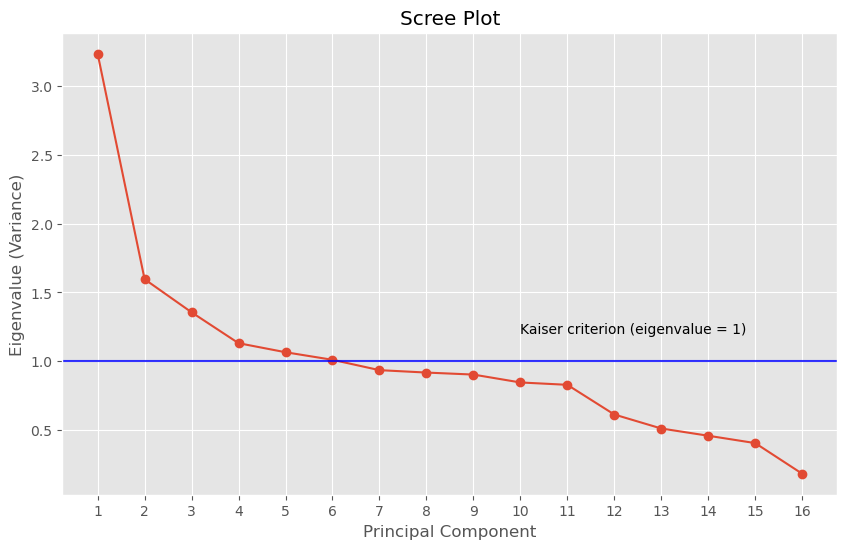

In [29]:
# Graphing a scree plot (eigenvalues)
plt.figure(figsize = (10, 6))
# Using range and len to create a sequence of numbers to use as the x-axis values that correspond with 16 principal components
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker = 'o')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue (Variance)')
plt.axhline(y = 1, color = 'blue', alpha = 0.8)
plt.xticks(range(1, len(eigenvalues) + 1))
plt.text(10, 1.2, 'Kaiser criterion (eigenvalue = 1)', fontsize = 10);

In [13]:
# Kaiser criterion
components = eigenvalues[eigenvalues > 1]
print(f'Number of components that have eigenvalues greater than 1: {len(components)}')

Number of components that have eigenvalues greater than 1: 6


In [14]:
# Eigenvalues (variance) of the six components identified by using Kaiser criterion
print(f"The eigenvalues of the six components: {components}")

The eigenvalues of the six components: [3.23405879 1.5963028  1.35591617 1.13163256 1.06586698 1.01091993]


In [15]:
# Final PCA with 6 components
pca = PCA(n_components = 6)
pca_transform = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_transform, columns = [f'PC {i+1}' for i in range(pca_transform.shape[1])])

# Adding the dependent variable Price to the PCA DataFrame
final_df = pd.concat([pca_df, pd.Series(y, name = 'Price')], axis = 1)
final_df

,PC 1,PC 2,PC 3,PC 4,PC 5,PC 6,Price
0,-0.906454,-0.633539,-0.274815,-1.531995,0.109145,-0.123291,255614.8992
1,-0.807884,-0.259993,0.686628,-0.866115,-1.687061,0.400225,155586.0947
2,-0.261683,3.055160,1.679027,-1.781387,0.803494,0.451694,131050.8324
3,-1.059663,-0.541531,0.124366,-0.173473,-0.174354,0.232971,151361.7125
4,-2.172205,0.160409,1.047683,-0.590920,-0.127632,-1.020908,113167.6128
...,...,...,...,...,...,...,...
6995,0.303622,-0.220292,-0.004118,-1.817204,-0.111242,0.279048,307821.1758
6996,1.667753,-0.019449,1.631116,2.034923,-0.184083,2.744670,421368.8869
6997,1.218464,-0.750410,-0.918291,-1.351930,0.674667,-2.057416,473382.5348
6998,2.424840,-0.910117,0.074106,-1.252649,-0.168734,-0.511076,343397.9756


In [16]:
# Splitting the data 80/20 into training and test datasets to avoid any data leakage
train_df, test_df = train_test_split(final_df, test_size = 0.2, random_state = 42)

# Shapes of the two datasets
print(f"Training dataset shape: {train_df.shape}")
print(f"Test dataset shape: {test_df.shape}")

Training dataset shape: (5600, 7)
Test dataset shape: (1400, 7)


In [17]:
# Saving the two datasets as CSV files
train_df.to_csv('Training Dataset.csv', index = False)
test_df.to_csv('Test Dataset.csv', index = False)

In [18]:
# Creating X_train, y_train, X_test, and y_test
X_train = train_df.drop('Price', axis = 1)
y_train = train_df['Price']
X_test = test_df.drop('Price', axis = 1)
y_test = test_df['Price']

# Shapes of X_train, y_train, X_test, and y_test
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5600, 6)
y_train shape: (5600,)
X_test shape: (1400, 6)
y_test shape: (1400,)


In [19]:
# Adding a constant (required for statsmodels)
X_train = sm.add_constant(X_train)

# Calculating VIF values
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]

vif_data.index = vif_data.index + 1 # Make the index start at 1 instead of 0
vif_data

,Feature,VIF
1,const,1.000240
2,PC 1,1.000065
3,PC 2,1.000154
4,PC 3,1.000117
5,PC 4,1.000073
6,PC 5,1.000052
7,PC 6,1.000228


In [20]:
# Initial linear regression
model = sm.OLS(y_train, X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.640
Method:                 Least Squares   F-statistic:                     1657.
Date:                Thu, 03 Apr 2025   Prob (F-statistic):               0.00
Time:                        08:58:59   Log-Likelihood:                -71877.
No. Observations:                5600   AIC:                         1.438e+05
Df Residuals:                    5593   BIC:                         1.438e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.081e+05   1213.973    253.768      0.000    3.06e+05     3.1e+05
PC 1        6.236e+04    670.826     92.964      0.000     6.1e+04    6.37e+04
PC 2       -1035.3169    968.394     -1.069      0.285   -2933.745     863.111
PC 3       -2.417e+04   1038.718    -23.267      0.000   -2.62e+04   -2.21e+04
PC 4        3.034e+04   1135.519     26.717      0.000    2.81e+04    3.26e+04
PC 5        5562.8442   1181.429      4.709      0.000    3246.784    7878.904
PC 6       -1291.6902   1210.079     -1.067      0.286   -3663.915    1080.534
==============================================================================
Omnibus:                      319.885   Durbin-Watson:                   1.980
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              405.393
Skew:                           0.556   Prob(JB):                     9.33e-89
Kurtosis:                       3.707   Cond. No.                         1.81
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [21]:
# Backward stepwise elimination
# Function will take in X and y
def backward_elimination(X, y, significance_level = 0.05):
    while True:
        model = sm.OLS(y, X).fit() # Fit the regression model
        p_values = model.pvalues.drop('const') # Get the p-values of the model and ignore the 'const'
        max_p_value = p_values.max() # Find the max p-value
        # If the max p-value is > than 0.05, drop the column (idxmax() returns the index of the highest p-value, which is the column name to drop from X) and continue the loop
        if max_p_value > significance_level:
            feature_to_drop = p_values.idxmax()
            print(f"Dropping {feature_to_drop} (p-value: {max_p_value:.4f})")
            X = X.drop(feature_to_drop, axis = 1)
        else:
            break # If max p-value is < 0.05, end the loop
    return model, X.columns.to_list()

# Creating optimized model using the backward_elimination function
optimized_model, selected_features = backward_elimination(X_train, y_train)
optimized_model.summary()

Dropping PC 6 (p-value: 0.2858)
Dropping PC 2 (p-value: 0.2893)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.640
Method:                 Least Squares   F-statistic:                     2485.
Date:                Thu, 03 Apr 2025   Prob (F-statistic):               0.00
Time:                        08:58:59   Log-Likelihood:                -71878.
No. Observations:                5600   AIC:                         1.438e+05
Df Residuals:                    5595   BIC:                         1.438e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.081e+05   1213.974    253.772      0.000    3.06e+05     3.1e+05
PC 1        6.236e+04    670.826     92.965      0.000     6.1e+04    6.37e+04
PC 3       -2.417e+04   1038.696    -23.273      0.000   -2.62e+04   -2.21e+04
PC 4        3.034e+04   1135.517     26.722      0.000    2.81e+04    3.26e+04
PC 5        5558.3979   1181.436      4.705      0.000    3242.324    7874.471
==============================================================================
Omnibus:                      320.019   Durbin-Watson:                   1.979
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              405.525
Skew:                           0.556   Prob(JB):                     8.73e-89
Kurtosis:                       3.707   Cond. No.                         1.81
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
# MSE of the optimized model used on the training dataset
# Capturing only the features that remained
X_train_final = X_train[selected_features]

y_train_pred = optimized_model.predict(X_train_final)
mse_train = mean_squared_error(y_train, y_train_pred)
print(f"Training MSE: {mse_train}")

Training MSE: 8243925450.8681135


In [23]:
# Running the prediction on the test dataset using the optimized regression model
# Adding constant
X_test = sm.add_constant(X_test)

# Keeping only the features used in the optimized model
X_test_final = X_test[selected_features]

# Making predictions on the test set
y_test_pred = optimized_model.predict(X_test_final)

# Calculating the test MSE
mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Test MSE: {mse_test}")

Test MSE: 8120432716.357522


In [24]:
# Actual Price vs. Predicted Price
actual_vs_predicted = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_test_pred, 'Difference': y_test - y_test_pred})
actual_vs_predicted

,Actual Price,Predicted Price,Difference
6500,588317.6568,386498.203527,201819.453273
2944,104021.6679,153950.541068,-49928.873168
2024,185708.2598,264854.883659,-79146.623859
263,128945.4664,141709.994380,-12764.527980
4350,343116.7513,468094.643163,-124977.891863
...,...,...,...
3484,122075.1750,133105.661805,-11030.486805
1860,145554.5086,248572.354435,-103017.845835
4974,301419.9178,277082.188054,24337.729746
387,216663.4381,192374.353576,24289.084524


In [25]:
# Training RMSE
rmse_train = np.sqrt(mse_train)
print(f"Training RMSE: {rmse_train}")

# Test RMSE
rmse_test = np.sqrt(mse_test)
print(f"Test RMSE: {rmse_test}")

# Difference between the RMSEs
print(f"Difference: {rmse_train - rmse_test}")

Training RMSE: 90796.06517282626
Test RMSE: 90113.4435939362
Difference: 682.621578890059
